# Asset Pricing and Portfolio Management | Heuristic portfolios

Python mirror of `lab-2.r`. Uses `yfinance` in place of `quantmod::getSymbols`,
`pandas`/`numpy` in place of `xts`, and hand-rolled helper functions in place of
`PerformanceAnalytics` (`table.AnnualizedReturns`, `table.DownsideRisk`,
`chart.CumReturns`, `charts.PerformanceSummary`, `chart.RiskReturnScatter`, `chart.Boxplot`).


In [103]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

pd.set_option("display.width", 120)
plt.rcParams["figure.figsize"] = (10, 6)


## Load stock price data and compute returns

In [104]:
# Download data from Yahoo Finance
begin_date = "2020-01-01"
end_date   = "2026-09-14"

# FAANG: Facebook (now Meta Platforms), Amazon, Apple, Netflix and Google (now Alphabet)
Tickers = ["GOOG", "NFLX", "AAPL", "AMZN", "META"]  # FAANG

prices = pd.DataFrame()
for ticker in Tickers:
    tmp = yf.download(ticker, start=begin_date, end=end_date, interval="1wk",
                       auto_adjust=False, progress=False)["Adj Close"]
    tmp = tmp.interpolate(limit_area="inside")  # interpolate NAs (like na.approx)
    prices[ticker] = tmp

prices.index.name = "Date"
prices.columns = Tickers


In [105]:
print(prices.info())
prices.head(3)


<class 'pandas.DataFrame'>
DatetimeIndex: 350 entries, 2020-01-01 to 2026-09-09
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   GOOG    350 non-null    float64
 1   NFLX    350 non-null    float64
 2   AAPL    350 non-null    float64
 3   AMZN    350 non-null    float64
 4   META    350 non-null    float64
dtypes: float64(5)
memory usage: 16.4 KB
None


,GOOG,NFLX,AAPL,AMZN,META
Date,,,,,
2020-01-01,69.013329,33.075001,71.799911,95.343002,211.205292
2020-01-08,70.872711,33.868999,75.238457,93.472000,217.153046
2020-01-15,73.523628,33.811001,76.174477,94.599998,219.512344


In [106]:
prices.tail(3)


,GOOG,NFLX,AAPL,AMZN,META
Date,,,,,
2026-08-26,331.814575,80.809998,325.130005,254.919998,578.539978
2026-09-02,335.380005,76.769997,316.220001,256.970001,613.479980
2026-09-09,335.450012,77.400002,332.269989,256.779999,648.030029


In [107]:
# compute log-returns and linear returns
X_log = np.log(prices / prices.shift(1)).iloc[1:]
X_lin = (prices / prices.shift(1) - 1).iloc[1:]

N = X_log.shape[1]  # number of stocks
T = X_log.shape[0]  # number of weeks
N, T


(5, 349)

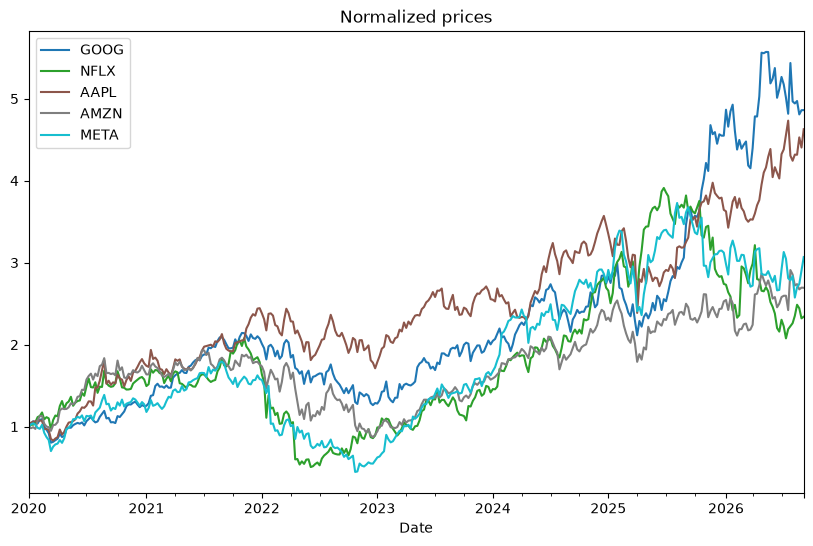

In [108]:
# First look at the prices of the stocks:
normalized = prices / prices.iloc[0]
normalized.plot(title="Normalized prices", colormap="tab10")
plt.legend(loc="upper left")
plt.show()


Divide the data into a training set (trn) and test set (tst)

In [109]:
T_trn = round(0.70 * T)  # 70% of data for training set
X_log_trn = X_log.iloc[:T_trn]
X_log_tst = X_log.iloc[T_trn:]
X_lin_trn = X_lin.iloc[:T_trn]
X_lin_tst = X_lin.iloc[T_trn:]


### Estimation of the expected return and covariance matrix

In [110]:
# Estimate directly from log returns
mu_log = X_log_trn.mean()
Sigma_log = X_log_trn.cov()
mu_log


GOOG    0.003148
NFLX    0.002915
AAPL    0.004557
AMZN    0.002594
META    0.003544
dtype: float64

In [111]:
def table_annualized_returns(X, scale=252, rf=0.0):
    """Mirrors PerformanceAnalytics::table.AnnualizedReturns."""
    ann_return = (1 + X).prod() ** (scale / len(X)) - 1
    ann_std = X.std(ddof=1) * np.sqrt(scale)
    ann_sharpe = (ann_return - rf) / ann_std
    return pd.DataFrame({
        "Annualized Return": ann_return,
        "Annualized Std Dev": ann_std,
        f"Annualized Sharpe (Rf={rf}%)": ann_sharpe,
    }).T

# Annualized returns (weekly data -> 52 periods/year)
table_annualized_returns(X_log_trn, scale=52, rf=0.0)


,GOOG,NFLX,AAPL,AMZN,META
Annualized Return,0.125926,-0.006185,0.212664,0.071122,0.069587
Annualized Std Dev,0.298407,0.516228,0.295353,0.360320,0.463679
Annualized Sharpe (Rf=0.0%),0.421994,-0.011981,0.720032,0.197384,0.150076


## Buy & Hold (B&H) Strategy

In [112]:
# Estimate mu and sigma from the in-sample log-returns:
mu = X_log_trn.mean()      # mean return
Sigma = X_log_trn.cov()    # var-cov matrix

# Var(daily) * 252 = Var(annual)
# sd(daily) * sqrt(252) = sd(annual)

# Buy & Hold simply means to allocate the whole budget to one stock and stick to it
# Since we have N stocks in our universe, we can define N different
# B&H portfolios, which we will store as column vectors

# a B&H portfolio is trivially the zero vector with a one on the stock held
w_BnH = pd.DataFrame(np.eye(N), index=X_lin.columns, columns=X_lin.columns)
w_BnH


,GOOG,NFLX,AAPL,AMZN,META
GOOG,1.0,0.0,0.0,0.0,0.0
NFLX,0.0,1.0,0.0,0.0,0.0
AAPL,0.0,0.0,1.0,0.0,0.0
AMZN,0.0,0.0,0.0,1.0,0.0
META,0.0,0.0,0.0,0.0,1.0


In [113]:
# compute the performance of those N portfolios in the training data
# compute returns of all B&H portfolios
ret_BnH = X_lin @ w_BnH
ret_BnH_trn = ret_BnH.iloc[:T_trn]
ret_BnH_tst = ret_BnH.iloc[T_trn:]
ret_BnH.head()


,GOOG,NFLX,AAPL,AMZN,META
Date,,,,,
2020-01-08,0.026942,0.024006,0.047891,-0.019624,0.028161
2020-01-15,0.037404,-0.001712,0.012441,0.012068,0.010865
2020-01-22,-0.021450,0.030789,0.003538,-0.020481,-0.016483
2020-01-29,-0.003779,0.058791,0.003652,0.105987,-0.036549
2020-02-05,0.042652,0.012683,0.004762,0.049340,-0.012582


### Performance measures

In [114]:
# Table of Annualized Return, Annualized Std Dev, and Annualized Sharpe
table_annualized_returns(ret_BnH_trn, scale=52, rf=0.0)


,GOOG,NFLX,AAPL,AMZN,META
Annualized Return,0.177856,0.163682,0.267397,0.144418,0.202333
Annualized Std Dev,0.296846,0.487864,0.295391,0.357278,0.448568
Annualized Sharpe (Rf=0.0%),0.599154,0.335508,0.905230,0.404216,0.451064


In [115]:
table_annualized_returns(ret_BnH_tst, scale=52, rf=0.0)


,GOOG,NFLX,AAPL,AMZN,META
Annualized Return,0.495796,0.071213,0.231305,0.193845,0.135441
Annualized Std Dev,0.337824,0.381512,0.328593,0.353829,0.366505
Annualized Sharpe (Rf=0.0%),1.467615,0.186659,0.703927,0.547850,0.369547


Note how the in-sample (ex ante) performance is not maintained out-of-sample (ex post).
We can compute many other performance measures:

In [116]:
def table_downside_risk(X, scale=52, mar=0.0):
    """Mirrors (a subset of) PerformanceAnalytics::table.DownsideRisk."""
    downside = X[X < mar]
    semi_dev = np.sqrt((downside.pow(2).sum()) / len(X))
    downside_dev = np.sqrt((downside.sub(mar).pow(2).sum()) / len(X))
    hist_var_95 = X.quantile(0.05)
    hist_es_95 = X[X <= hist_var_95.reindex(X.columns)].mean() if False else X.apply(
        lambda col: col[col <= col.quantile(0.05)].mean()
    )
    return pd.DataFrame({
        "Semi Deviation": semi_dev,
        "Downside Deviation (MAR = 0%)": downside_dev,
        "Historical VaR (95%)": hist_var_95,
        "Historical ES (95%)": hist_es_95,
        "Maximum Drawdown": (X.cumsum().cummax() - X.cumsum()).max(),
    }).T

table_downside_risk(ret_BnH_trn)


,GOOG,NFLX,AAPL,AMZN,META
Semi Deviation,0.028217,0.047745,0.026564,0.033888,0.044137
Downside Deviation (MAR = 0%),0.028217,0.047745,0.026564,0.033888,0.044137
Historical VaR (95%),-0.067310,-0.088171,-0.059428,-0.080580,-0.081858
Historical ES (95%),-0.094123,-0.147476,-0.085236,-0.114808,-0.145581
Maximum Drawdown,0.455313,1.136057,0.314388,0.617941,1.149241


To compute the wealth or cumulative P&L, we have two options: one assumes the
same quantity is repeatedly invested, whereas the other assumes reinvesting (compounding):

In [117]:
# Compute cumulative wealth
# A. same quantity is repeatedly invested
wealth_arith_BnH_trn = 1 + ret_BnH_trn.cumsum()  # initial budget of 1$

# B. Assume reinvesting (compounding):
wealth_geom_BnH_trn = (1 + ret_BnH_trn).cumprod()  # initial budget of 1$
wealth_geom_BnH_trn.head(3)


,GOOG,NFLX,AAPL,AMZN,META
Date,,,,,
2020-01-08,1.026942,1.024006,1.047891,0.980376,1.028161
2020-01-15,1.065354,1.022252,1.060927,0.992207,1.039332
2020-01-22,1.042502,1.053726,1.064680,0.971886,1.022200


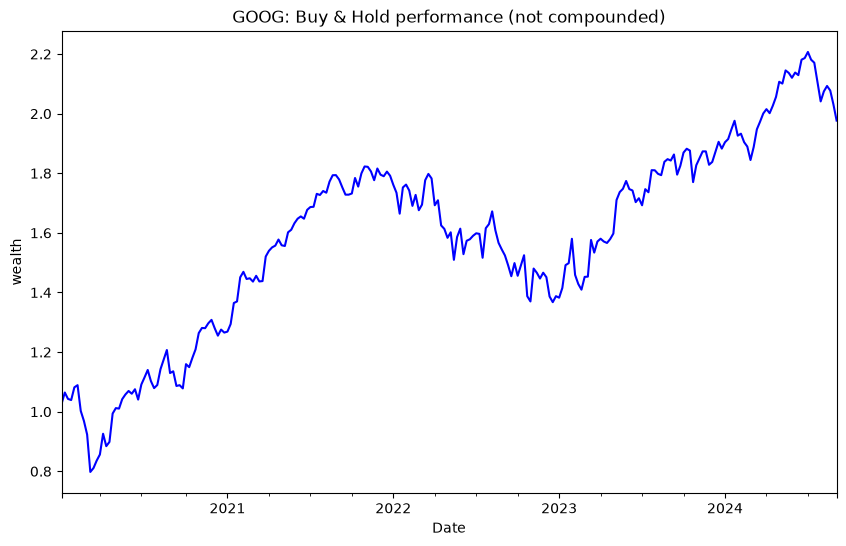

In [118]:
# plots
def chart_cum_returns(ret, geometric=True, title="", **kwargs):
    wealth = (1 + ret).cumprod() if geometric else 1 + ret.cumsum()
    ax = wealth.plot(title=title, **kwargs)
    ax.set_ylabel("wealth")
    return ax

chart_cum_returns(ret_BnH_trn["GOOG"], geometric=False,
                   title=f"{Tickers[0]}: Buy & Hold performance (not compounded)", color="blue")
plt.show()


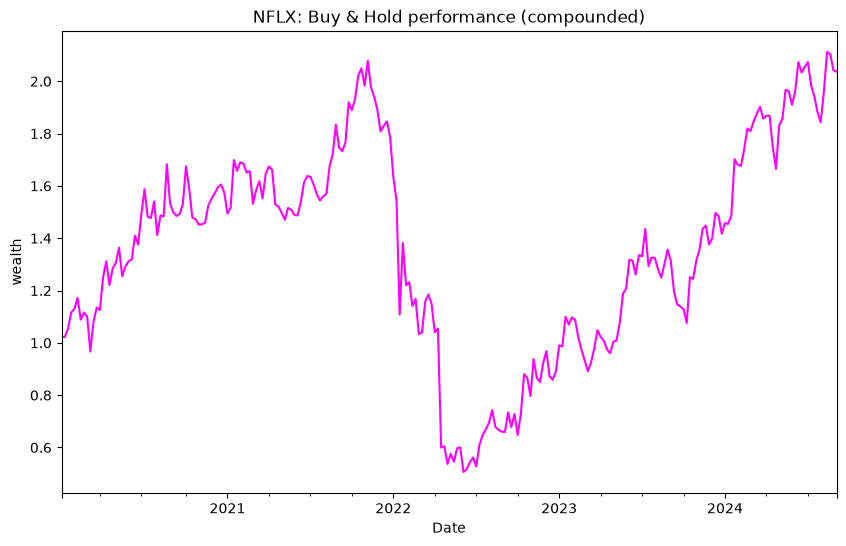

In [119]:
chart_cum_returns(ret_BnH_trn["NFLX"], geometric=True,
                   title=f"{Tickers[1]}: Buy & Hold performance (compounded)", color="magenta")
plt.show()


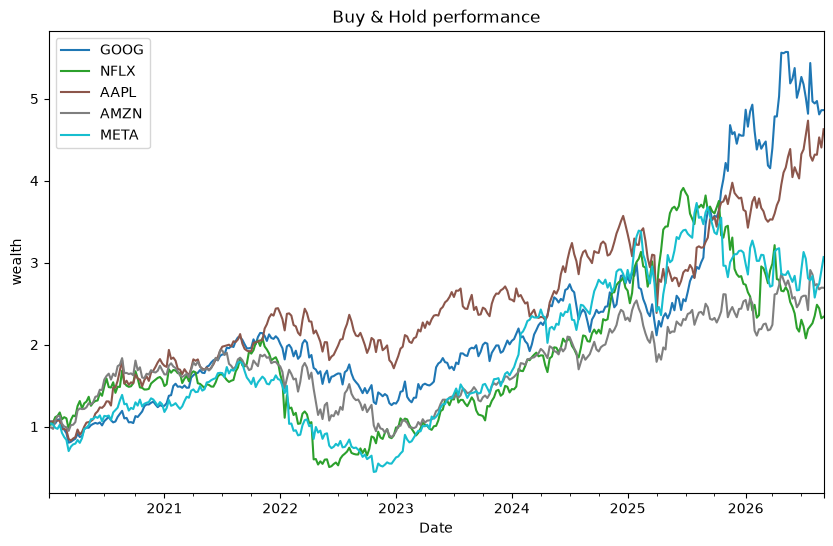

In [120]:
# more plots
chart_cum_returns(ret_BnH, geometric=True, title="Buy & Hold performance", colormap="tab10")
plt.legend(loc="upper left")
plt.show()


### Combined wealth index, period performance, and drawdown chart

Note: Drawdown: Any time the cumulative returns dips below the maximum cumulative returns,
it's a drawdown. Drawdowns are measured as a percentage of that maximum cumulative return,
in effect, measured from peak equity.

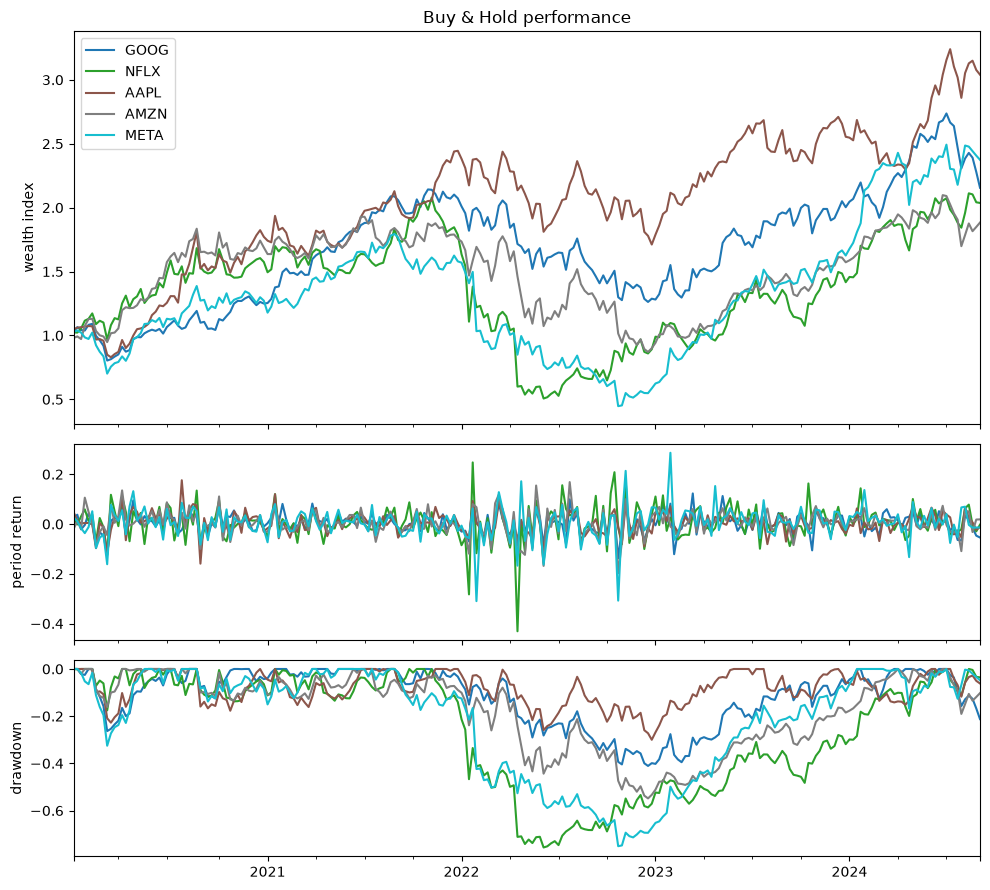

In [121]:
def charts_performance_summary(ret, title=""):
    """Mirrors PerformanceAnalytics::charts.PerformanceSummary: wealth index,
    period returns, and drawdown stacked vertically."""
    wealth = (1 + ret).cumprod()
    drawdown = wealth / wealth.cummax() - 1

    fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True,
                              gridspec_kw={"height_ratios": [2, 1, 1]})
    wealth.plot(ax=axes[0], colormap="tab10", legend=True)
    axes[0].set_ylabel("wealth index")
    axes[0].set_title(title)

    ret.plot(ax=axes[1], colormap="tab10", legend=False)
    axes[1].set_ylabel("period return")

    drawdown.plot(ax=axes[2], colormap="tab10", legend=False)
    axes[2].set_ylabel("drawdown")
    axes[2].set_xlabel("")

    fig.tight_layout()
    return fig

charts_performance_summary(ret_BnH_trn, title="Buy & Hold performance")
plt.show()


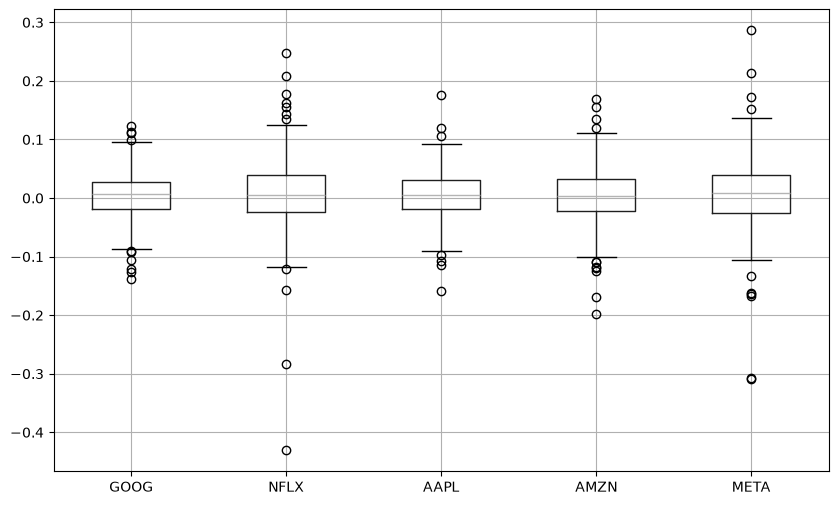

In [122]:
def chart_boxplot(ret, title=""):
    fig, ax = plt.subplots()
    ret.boxplot(ax=ax)
    ax.set_title(title)
    return fig

chart_boxplot(ret_BnH_trn)
plt.show()


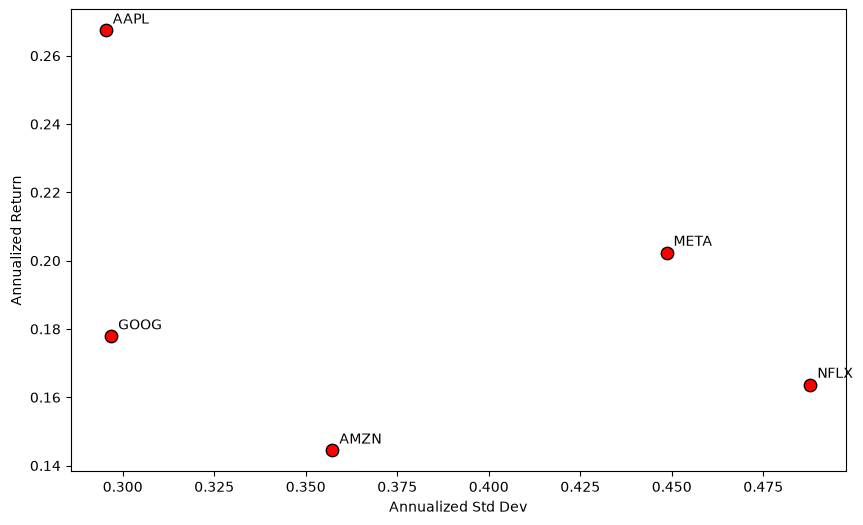

In [123]:
def chart_risk_return_scatter(ret, scale=52, title=""):
    ann_return = (1 + ret).prod() ** (scale / len(ret)) - 1
    ann_std = ret.std(ddof=1) * np.sqrt(scale)
    fig, ax = plt.subplots()
    ax.scatter(ann_std, ann_return, s=80, marker="o", facecolor="red", edgecolor="black")
    for name in ret.columns:
        ax.annotate(name, (ann_std[name], ann_return[name]), textcoords="offset points", xytext=(5, 5))
    ax.set_xlabel("Annualized Std Dev")
    ax.set_ylabel("Annualized Return")
    ax.set_title(title)
    return fig

# Annualized risk and return
chart_risk_return_scatter(ret_BnH_trn)
plt.show()


## R session: Comparison of 1/N portfolio, quintile portfolio, and GMRP

In [124]:
w_EWP = pd.Series(1 / N, index=X_lin.columns)
w_EWP


GOOG    0.2
NFLX    0.2
AAPL    0.2
AMZN    0.2
META    0.2
dtype: float64

In [125]:
# find indices of sorted stocks (descending)
i1 = mu.sort_values(ascending=False).index.tolist()
i2 = (mu / np.diag(Sigma)).sort_values(ascending=False).index.tolist()
i3 = (mu / np.sqrt(np.diag(Sigma))).sort_values(ascending=False).index.tolist()

pd.DataFrame({"i1": i1, "i2": i2, "i3": i3})


,i1,i2,i3
0,AAPL,AAPL,AAPL
1,META,GOOG,GOOG
2,GOOG,AMZN,META
3,NFLX,META,AMZN
4,AMZN,NFLX,NFLX


In [126]:
Tickers


['GOOG', 'NFLX', 'AAPL', 'AMZN', 'META']

Quintile portfolios
Steps: 1) rank the N stocks
       2) divide them into five parts
       3) long the top part (and possibly short the bottom part)

In [127]:
# create portfolios
n_top = round(N / 5)

w_QuintP_1 = pd.Series(0.0, index=X_lin.columns)
w_QuintP_2 = pd.Series(0.0, index=X_lin.columns)
w_QuintP_3 = pd.Series(0.0, index=X_lin.columns)

w_QuintP_1[i1[:n_top]] = 1 / n_top
w_QuintP_2[i2[:n_top]] = 1 / n_top
w_QuintP_3[i3[:n_top]] = 1 / n_top

w_QuintP = pd.DataFrame({
    "QuintP (mu)": w_QuintP_1,
    "QuintP (mu/sigma2)": w_QuintP_2,
    "QuintP (mu/sigma)": w_QuintP_3,
})
w_QuintP


,QuintP (mu),QuintP (mu/sigma2),QuintP (mu/sigma)
GOOG,0.0,0.0,0.0
NFLX,0.0,0.0,0.0
AAPL,1.0,1.0,1.0
AMZN,0.0,0.0,0.0
META,0.0,0.0,0.0


Global maximum return portfolio (GMRP)
GMRP chooses the stock with the highest return during the in-sample period

In [128]:
i_max = mu.idxmax()
w_GMRP = pd.Series(0.0, index=X_lin.columns)
w_GMRP[i_max] = 1.0
w_GMRP


GOOG    0.0
NFLX    0.0
AAPL    1.0
AMZN    0.0
META    0.0
dtype: float64

In [129]:
# put together all portfolios
w_heuristic = pd.concat([w_EWP.rename("EWP"), w_QuintP, w_GMRP.rename("GMRP")], axis=1)
w_heuristic.round(2)


,EWP,QuintP (mu),QuintP (mu/sigma2),QuintP (mu/sigma),GMRP
GOOG,0.2,0.0,0.0,0.0,0.0
NFLX,0.2,0.0,0.0,0.0,0.0
AAPL,0.2,1.0,1.0,1.0,1.0
AMZN,0.2,0.0,0.0,0.0,0.0
META,0.2,0.0,0.0,0.0,0.0


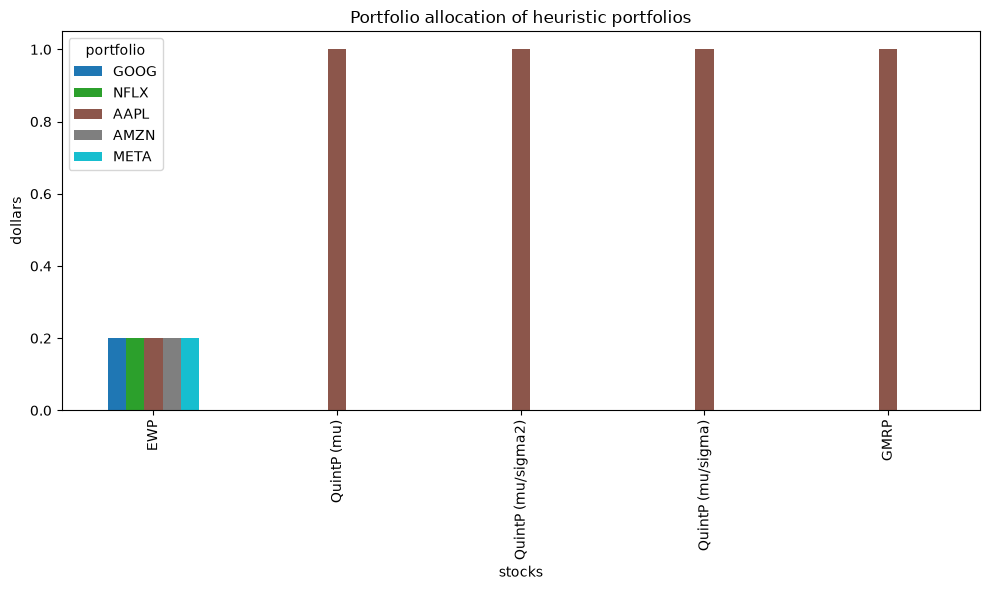

In [130]:
w_heuristic.T.plot(kind="bar", colormap="tab10", title="Portfolio allocation of heuristic portfolios")
plt.xlabel("stocks")
plt.ylabel("dollars")
plt.legend(title="portfolio")
plt.tight_layout()
plt.show()


Then we can compare the performance (in-sample vs out-of-sample):

In [131]:
# compute returns of all portfolios
ret_heuristic = X_lin @ w_heuristic
ret_heuristic = ret_heuristic.drop(columns=["QuintP (mu/sigma2)"])  # coincides with "QuintP (mu/sigma)"
ret_heuristic_trn = ret_heuristic.iloc[:T_trn]  # training set
ret_heuristic_tst = ret_heuristic.iloc[T_trn:]  # test set


In [132]:
# Performance metrics
table_annualized_returns(ret_heuristic_trn, scale=52, rf=0.0)


,EWP,QuintP (mu),QuintP (mu/sigma),GMRP
Annualized Return,0.227072,0.267397,0.267397,0.267397
Annualized Std Dev,0.302384,0.295391,0.295391,0.295391
Annualized Sharpe (Rf=0.0%),0.750940,0.905230,0.905230,0.905230


In [133]:
table_annualized_returns(ret_heuristic_tst, scale=52, rf=0.0)


,EWP,QuintP (mu),QuintP (mu/sigma),GMRP
Annualized Return,0.258766,0.231305,0.231305,0.231305
Annualized Std Dev,0.239102,0.328593,0.328593,0.328593
Annualized Sharpe (Rf=0.0%),1.082240,0.703927,0.703927,0.703927


Let's plot the wealth evolution (cumulative PnL) over time:

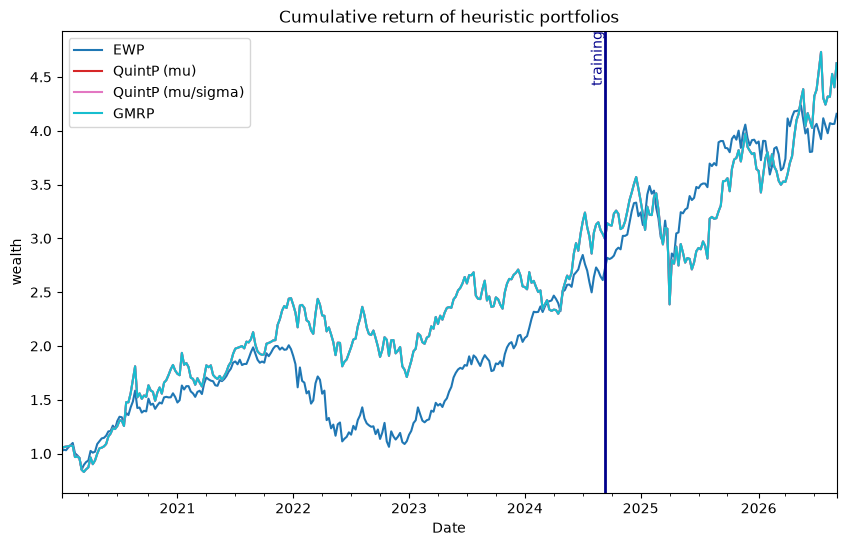

In [134]:
ax = chart_cum_returns(ret_heuristic, geometric=True,
                        title="Cumulative return of heuristic portfolios", colormap="tab10")
plt.legend(loc="upper left")
ax.axvline(X_lin.index[T_trn], color="darkblue", lw=2)
ax.annotate("training", (X_lin.index[T_trn], ax.get_ylim()[1]), rotation=90,
            va="top", ha="right", color="darkblue")
plt.show()


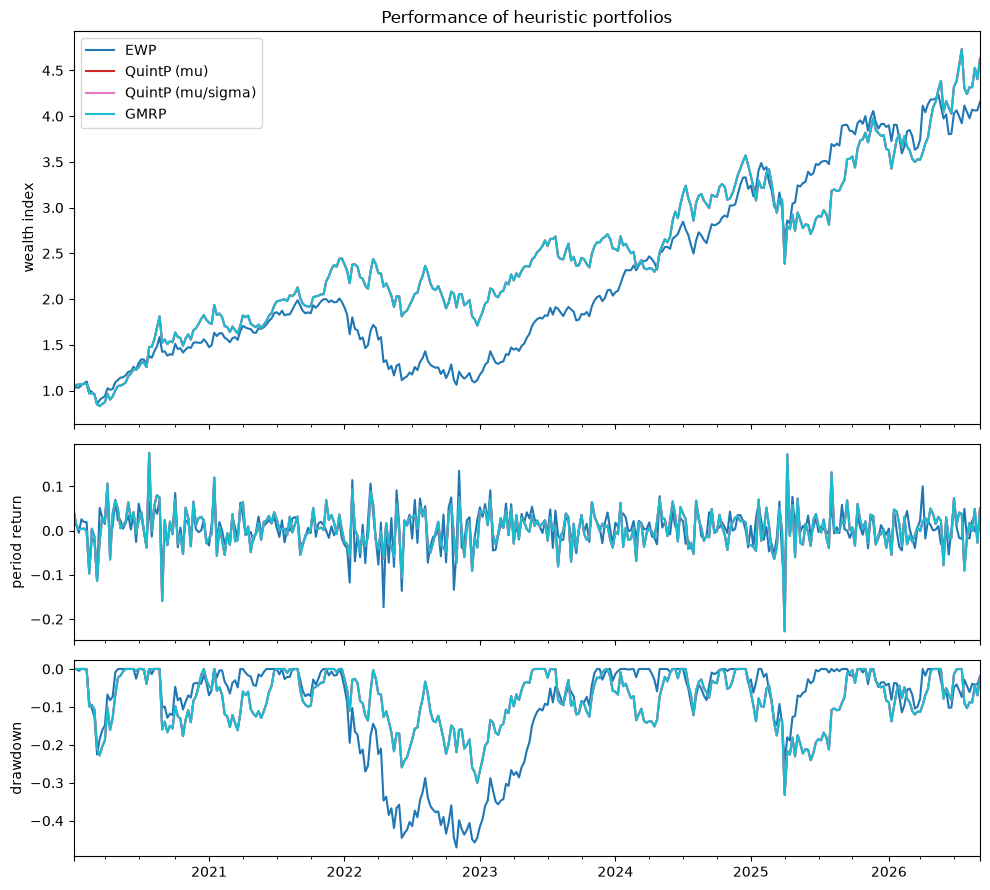

In [135]:
charts_performance_summary(ret_heuristic, title="Performance of heuristic portfolios")
plt.show()


Finally, we can plot the risk-return scatter plot:

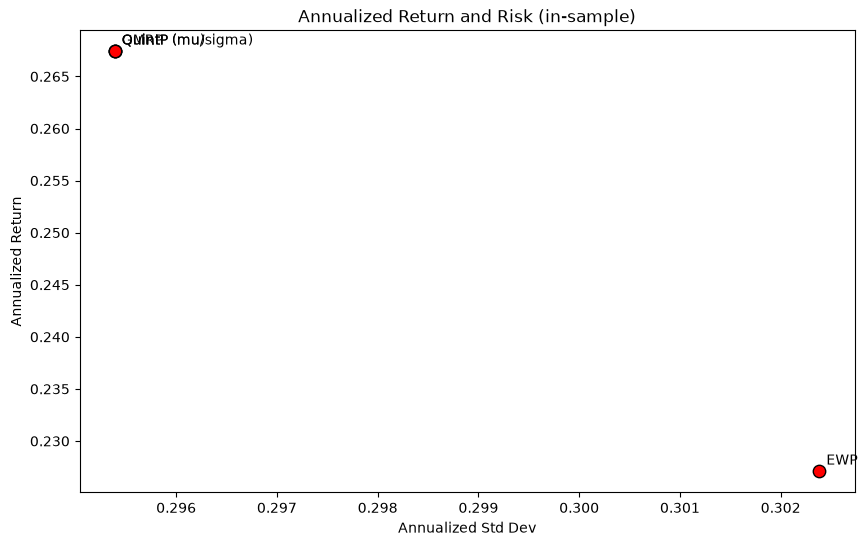

In [136]:
chart_risk_return_scatter(ret_heuristic_trn, title="Annualized Return and Risk (in-sample)")
plt.show()
